# Лабораторная работа 6

**Тема:** алгоритмы Actor-Critic.

Реализован Advantage Actor-Critic для среды `CartPole-v1`. Актор выбирает действие, критик оценивает ценность состояния.

In [1]:
import importlib.util
import subprocess
import sys


def ensure(package, import_name=None):
    import_name = import_name or package
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

for package, import_name in [('numpy', 'numpy'), ('matplotlib', 'matplotlib'), ('gymnasium', 'gymnasium'), ('pandas', 'pandas')]:
    ensure(package, import_name)

import time
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

ensure('torch', 'torch')
import torch
import torch.nn as nn
import torch.optim as optim

ENV_NAME = 'CartPole-v1'
RANDOM_STATE = 42

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [2]:
class ActorCritic(nn.Module):
    def __init__(self, obs_dim, n_actions):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(obs_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
        )
        self.actor = nn.Linear(128, n_actions)
        self.critic = nn.Linear(128, 1)

    def forward(self, x):
        hidden = self.shared(x)
        logits = self.actor(hidden)
        value = self.critic(hidden).squeeze(-1)
        return logits, value

In [3]:
def discounted_returns(rewards, gamma):
    total = 0.0
    returns = []
    for reward in reversed(rewards):
        total = reward + gamma * total
        returns.append(total)
    returns = torch.tensor(list(reversed(returns)), dtype=torch.float32)
    if len(returns) > 1:
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)
    return returns


def train_actor_critic(episodes=300, gamma=0.99, lr=2e-3):
    env = gym.make(ENV_NAME)
    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n
    model = ActorCritic(obs_dim, n_actions)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    episode_rewards = []
    losses = []
    started = time.perf_counter()

    for episode in range(episodes):
        obs, _ = env.reset(seed=4000 + episode)
        log_probs, values, rewards, entropies = [], [], [], []

        for _ in range(500):
            state = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
            logits, value = model(state)
            dist = torch.distributions.Categorical(logits=logits)
            action = dist.sample()
            next_obs, reward, terminated, truncated, _ = env.step(int(action.item()))

            log_probs.append(dist.log_prob(action).squeeze())
            values.append(value.squeeze())
            entropies.append(dist.entropy().squeeze())
            rewards.append(float(reward))
            obs = next_obs

            if terminated or truncated:
                break

        returns = discounted_returns(rewards, gamma)
        values = torch.stack(values)
        log_probs = torch.stack(log_probs)
        entropies = torch.stack(entropies)
        advantages = returns - values

        actor_loss = -(log_probs * advantages.detach()).mean()
        critic_loss = advantages.pow(2).mean()
        entropy_bonus = entropies.mean()
        loss = actor_loss + 0.5 * critic_loss - 0.01 * entropy_bonus

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        episode_rewards.append(sum(rewards))
        losses.append(float(loss.detach()))

    env.close()
    return model, np.array(episode_rewards), np.array(losses), time.perf_counter() - started

In [4]:
model, rewards, losses, train_time = train_actor_critic()
print('Средняя награда за последние 50 эпизодов:', rewards[-50:].mean().round(2))
print('Лучшая награда:', rewards.max())
print('Время обучения, сек:', round(train_time, 2))

Средняя награда за последние 50 эпизодов: 374.96
Лучшая награда: 500.0
Время обучения, сек: 13.88


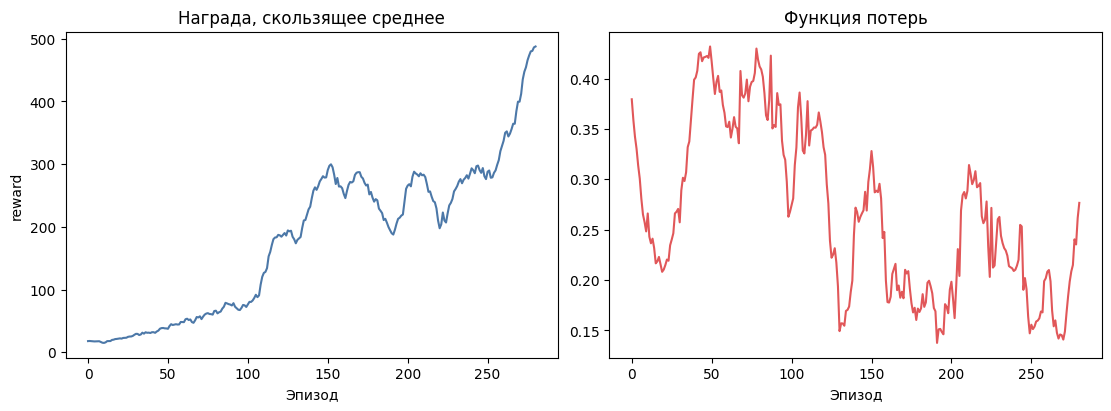

In [5]:
def moving_average(values, window=20):
    values = np.asarray(values, dtype=float)
    if len(values) < window:
        return values
    return np.convolve(values, np.ones(window) / window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(moving_average(rewards, 20), color='#4c78a8')
axes[0].set_title('Награда, скользящее среднее')
axes[0].set_xlabel('Эпизод')
axes[0].set_ylabel('reward')
axes[1].plot(moving_average(losses, 20), color='#e15759')
axes[1].set_title('Функция потерь')
axes[1].set_xlabel('Эпизод')
plt.show()

In [6]:
def evaluate(model, episodes=20):
    env = gym.make(ENV_NAME)
    scores = []
    model.eval()
    with torch.no_grad():
        for episode in range(episodes):
            obs, _ = env.reset(seed=7000 + episode)
            total = 0.0
            for _ in range(500):
                state = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
                logits, _ = model(state)
                action = int(torch.argmax(logits, dim=-1).item())
                obs, reward, terminated, truncated, _ = env.step(action)
                total += reward
                if terminated or truncated:
                    break
            scores.append(total)
    env.close()
    model.train()
    return np.array(scores)

scores = evaluate(model)
print('Оценка политики: mean =', scores.mean().round(2), ', std =', scores.std().round(2))

Оценка политики: mean = 500.0 , std = 0.0


Actor-Critic обучается без таблицы состояний: политика и функция ценности задаются нейронной сетью, поэтому метод напрямую работает с непрерывными наблюдениями среды.